In [47]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("数据.csv")  # 这里已经把“数据.csv”文件移到本目录下方
# print(df)
# print(df.to_string())
# 如果不使用to_string()，则输出结果为数据的前面 5 行和末尾 5 行，中间部分以 ... 代替

# 输出所有发布部门
# print(df.发布部门.to_string())
total_count = len(df.发布部门)
print(f"总的通知数: {total_count}\n")
cnt = df.发布部门.value_counts()
per = (df.发布部门.value_counts(normalize=True)*100).round(2)    
print(cnt)
print("\n发布的通知数量占总数的比例")
print(per)


总的通知数: 800

发布部门
【教学运行】    247
【实践科】     209
【质量办】      93
【计划科】      89
【教研教改】     68
【综合科】      57
【教材中心】     30
【教学通知】      6
【电教中心】      1
Name: count, dtype: int64

发布的通知数量占总数的比例
发布部门
【教学运行】    30.88
【实践科】     26.12
【质量办】     11.62
【计划科】     11.12
【教研教改】     8.50
【综合科】      7.12
【教材中心】     3.75
【教学通知】     0.75
【电教中心】     0.12
Name: proportion, dtype: float64


平均附件下载次数最高的前10个部门：
        平均下载次数     总下载次数  通知数量
发布部门                          
【实践科】   874.14  182696.0   209
【教学运行】  537.11  132667.0   247
【计划科】   290.10   25819.0    89
【质量办】   251.88   23425.0    93
【教学通知】   89.67     538.0     6
【综合科】    64.26    3663.0    57
【教研教改】   60.76    4132.0    68
【教材中心】   57.70    1731.0    30
【电教中心】    0.00       0.0     1


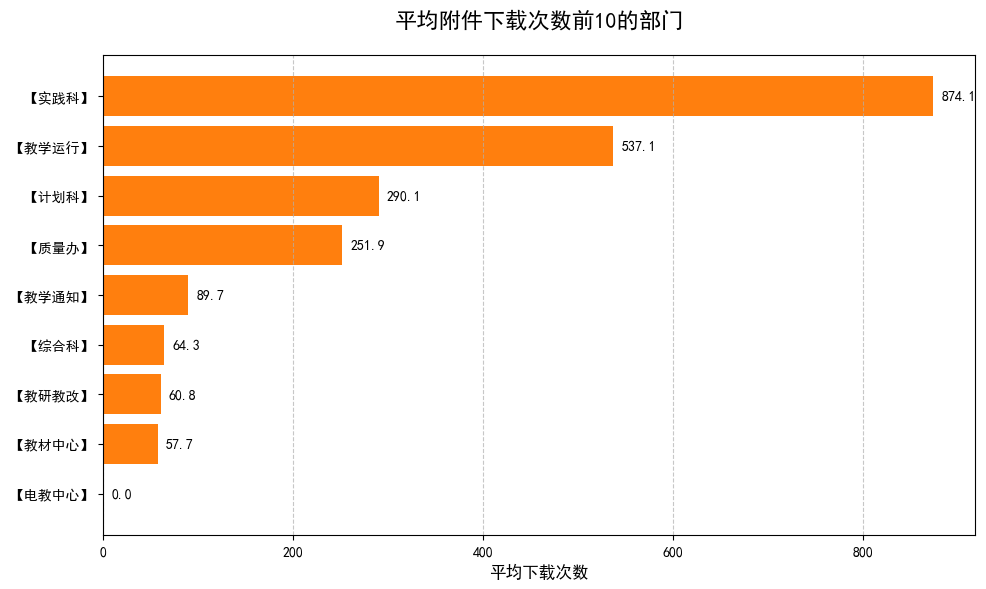

In [51]:
import re

df = pd.read_csv("数据.csv")
# 处理['2883']格式的字符串替换掉无关字符
df['附件下载次数'] = df['附件下载次数'].str.replace(r"[\[\]']", "", regex=True)

# 将清洗后的字符串转为数值型，无法转换的转为NaN
df['附件下载次数'] = pd.to_numeric(df['附件下载次数'], errors='coerce')
# 填充NaN为0（数值型0）
df['附件下载次数'] = df['附件下载次数'].fillna(0)

# 分组聚合计算统计指标
dept_stats = df.groupby('发布部门').agg({
    '附件下载次数': ['mean', 'sum', 'count']
}).round(2)
# 重命名列名
dept_stats.columns = ['平均下载次数', '总下载次数', '通知数量']
# 按平均下载次数降序排序
dept_stats_sorted = dept_stats.sort_values(by='平均下载次数', ascending=False)

print("平均附件下载次数最高的前10个部门：")
print(dept_stats_sorted.head(10))

# 3. 提取平均下载次数前10的部门数据
top10_mean = dept_stats.sort_values(by='平均下载次数', ascending=False)['平均下载次数'].head(10)

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制横向柱状图
bars = ax.barh(top10_mean.index[::-1], top10_mean.values[::-1], color='#ff7f0e')

# 图表样式优化
ax.set_title('平均附件下载次数前10的部门', fontsize=16, pad=20)
ax.set_xlabel('平均下载次数', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.7) 

# 由豆包提供
# 在柱子右侧显示具体数值
for bar in bars:
    width = bar.get_width()
    ax.text(width + max(top10_mean.values)*0.01, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}', ha='left', va='center', fontsize=10)

# 调整布局，避免数值/标签被裁剪
plt.tight_layout()

plt.show()



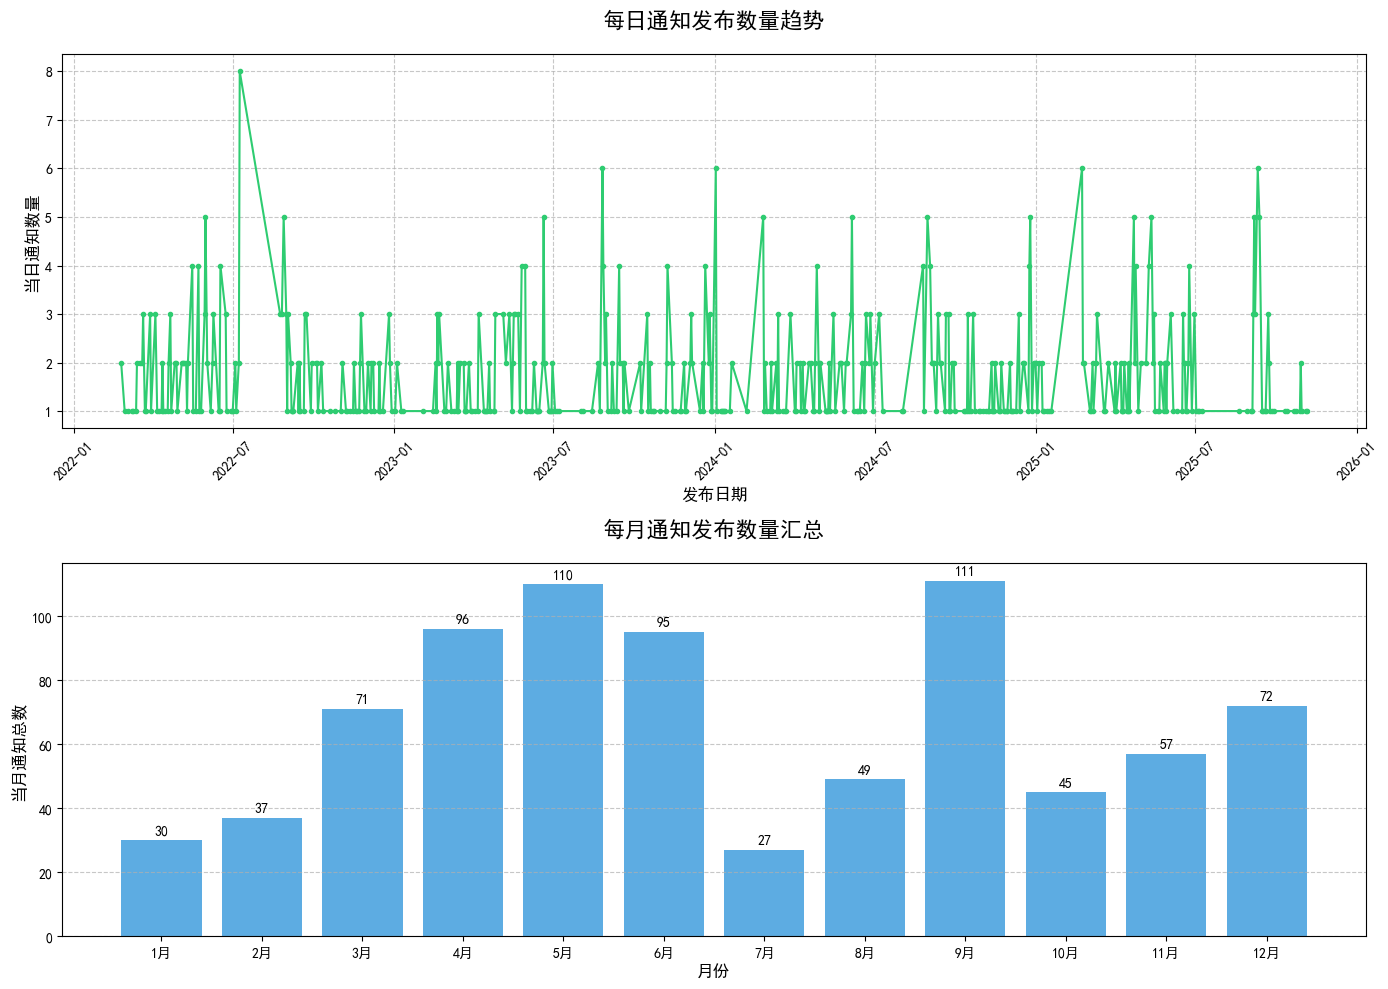

In [53]:
df = pd.read_csv("数据.csv")

# 日期处理
# 转换发布日期为datetime类型（处理异常值为NaT）
df['发布日期'] = pd.to_datetime(df['发布日期'], errors='coerce')
# 过滤掉日期为空的数据
df = df.dropna(subset=['发布日期'])

# 统计每天的通知发布数量
daily_count = df.groupby(df['发布日期'].dt.date).size()  # 按日期分组计数
# 转换为DataFrame，方便后续处理
daily_count_df = daily_count.reset_index()
daily_count_df.columns = ['发布日期', '通知数量']
# 按日期排序
daily_count_df = daily_count_df.sort_values(by='发布日期')

# 按月份
daily_count_df['月份'] = pd.to_datetime(daily_count_df['发布日期']).dt.month
monthly_count = daily_count_df.groupby('月份')['通知数量'].sum()

# 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 每日通知数量趋势
ax1.plot(daily_count_df['发布日期'], daily_count_df['通知数量'], 
         color='#2ecc71', linewidth=1.5, marker='o', markersize=3)
ax1.set_title('每日通知发布数量趋势', fontsize=16, pad=20)
ax1.set_xlabel('发布日期', fontsize=12)
ax1.set_ylabel('当日通知数量', fontsize=12)
ax1.grid(linestyle='--', alpha=0.7)
# 旋转x轴日期标签，避免重叠
ax1.tick_params(axis='x', rotation=45)

# 每月通知数量汇总
month_names = ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月']
# 按1-12月填充（无数据的月份数量为0）
monthly_count_full = pd.Series(0, index=range(1,13))
for month in monthly_count.index:
    monthly_count_full[month] = monthly_count[month]

ax2.bar(month_names, monthly_count_full.values, color='#3498db', alpha=0.8)
ax2.set_title('每月通知发布数量汇总', fontsize=16, pad=20)
ax2.set_xlabel('月份', fontsize=12)
ax2.set_ylabel('当月通知总数', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
# 在柱子上方显示数值
for i, v in enumerate(monthly_count_full.values):
    ax2.text(i, v + max(monthly_count_full.values)*0.01, f'{int(v)}', ha='center', va='bottom', fontsize=10)

# 调整布局
plt.tight_layout()
plt.show()


# value_counts()
value_counts() 是 pandas.Series（一维数组）的内置方法，核心作用是统计一维数据中每个唯一值出现的次数（频次），返回的结果是一个新的 Series：
新 Series 的索引是原数据的唯一值；新 Series 的值是对应唯一值出现的次数；默认按频次从高到低降序排列。

```python 
# 导入pandas库（使用前必须导入）
import pandas as pd

# 创建示例Series（模拟分类数据：水果类型）
fruit_series = pd.Series(['苹果', '香蕉', '苹果', '橙子', '香蕉', '苹果', '葡萄', '香蕉', None])

# 调用value_counts()统计频次
count_result = fruit_series.value_counts()

# 打印结果
print("基础统计结果：")
print(count_result)
```

输出结果为：
```plaintext
苹果    3
香蕉    3
橙子    1
葡萄    1
dtype: int64
```

## pd.to_numeric() 
### 核心定义

`pd.to_numeric()` 是 pandas 函数，核心作用是**将非数值型数据（如字符串、混合类型）转换为数值类型（int/float）**，解决数据类型不统一、无法做数值计算的问题。

### 极简示例

```
import pandas as pd

# 字符串转数值
s = pd.Series(['10', '25.5', '30'])
num_s = pd.to_numeric(s)
print(num_s)  # 输出：0    10.0  1    25.5  2    30.0  dtype: float64

# 处理无法转换的值（核心参数 errors='coerce'）
s2 = pd.Series(['10', 'abc', '25.5'])
num_s2 = pd.to_numeric(s2, errors='coerce')  # 无法转的设为NaN
print(num_s2)  # 输出：0    10.0  1     NaN  2    25.5  dtype: float64
```

### 关键参数

- `errors`：控制转换失败的处理逻辑
    - `coerce`：无法转换 → NaN（最常用）
    - `raise`：报错（默认）
    - `ignore`：保留原数据

## sort_values()

### 核心定义

`sort_values()` 是 pandas Series/DataFrame 的排序方法，核心作用是**按数值大小对数据进行升序 / 降序排序**，是数据整理的高频操作（区别于按索引排序的 `sort_index()`）。

### 极简示例

```
import pandas as pd

# 1. Series排序（无需指定列）
s = pd.Series([5, 2, 8, 1])
s_sorted = s.sort_values()  # 默认升序
print(s_sorted)  # 输出：3    1  1    2  0    5  2    8  dtype: int64

# 2. DataFrame排序（需指定排序列）
df = pd.DataFrame({'A': [3, 1, 2], 'B': [9, 7, 8]})
df_sorted = df.sort_values(by='A', ascending=False)  # 按A列降序
print(df_sorted)
#    A  B
# 0  3  9
# 2  2  8
# 1  1  7
```

### 关键参数（精简版）

- `by`：仅 DataFrame 需指定，传入**列名**（如 `by='A'`），表示按该列排序；
- `ascending`：`True`= 升序（默认），`False`= 降序；
- `na_position`：控制 NaN 位置，`last`（默认，NaN 放最后）/`first`（NaN 放最前）。

### 总结

1. `sort_values()` 核心是**按数值对 Series/DataFrame 排序**；
2. DataFrame 需用 `by` 指定排序列，`ascending` 控制升降序；
3. 可通过 `na_position` 调整 NaN 值的排序位置。